# Survey v1.1 — Visualisations
Plots covering four areas: **Measure Types**, **Building Characteristics**, **Sociodemographics**, and **Triggers & Subsidies**.

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/processed/survey_v1.1.json"

with open(DATA_PATH) as f:
    data = json.load(f)

N = len(data)
print(f"Loaded {N} records, {len(data[0])} fields each.")

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Colour palette (one per section)
C_MEAS  = "#4C72B0"   # blue  – measures
C_BUILD = "#55A868"   # green – building
C_SOCIO = "#C44E52"   # red   – sociodemographics
C_TRIG  = "#DD8452"   # orange – triggers & subsidies

def pct_of(values, total=None):
    """Return list of percentages."""
    t = total or sum(values)
    return [v / t * 100 for v in values]

def get_field(field, cast=str):
    """Return non-null values of a field, cast to type."""
    return [cast(r[field]) for r in data if r.get(field) is not None]

Loaded 1651 records, 143 fields each.


---
## 1 · Measure Types

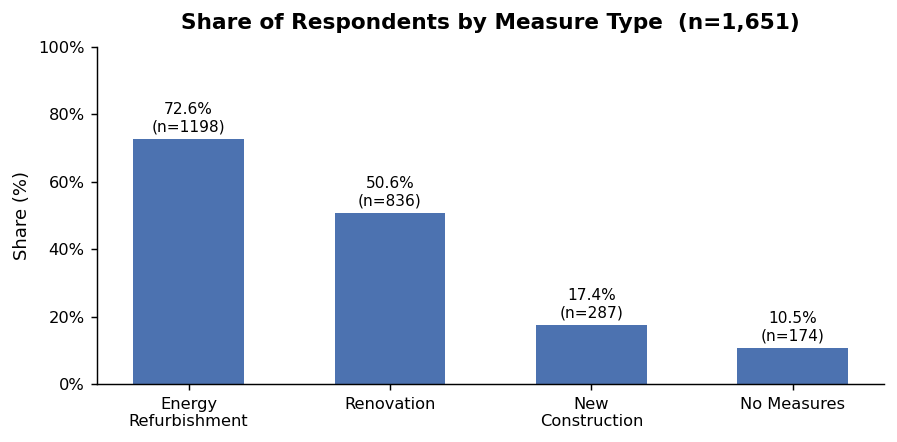

In [11]:
# ── 1a: Overview bar — share of respondents per measure type ──────────────────
meas_fields  = ["MEAS_REF", "MEAS_REN", "MEAS_NEW", "MEAS_NO"]
meas_labels  = [
    "Energy\nRefurbishment",
    "Renovation",
    "New\nConstruction",
    "No Measures",
]

yes_counts = [sum(1 for r in data if str(r.get(f, '0')) == '1') for f in meas_fields]
yes_pcts   = pct_of(yes_counts, N)

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(meas_labels, yes_pcts, color=C_MEAS, width=0.55)
ax.set_title("Share of Respondents by Measure Type  (n=1,651)", pad=10)
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
for bar, pct, cnt in zip(bars, yes_pcts, yes_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{pct:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=8.5)
plt.tight_layout()
plt.show()

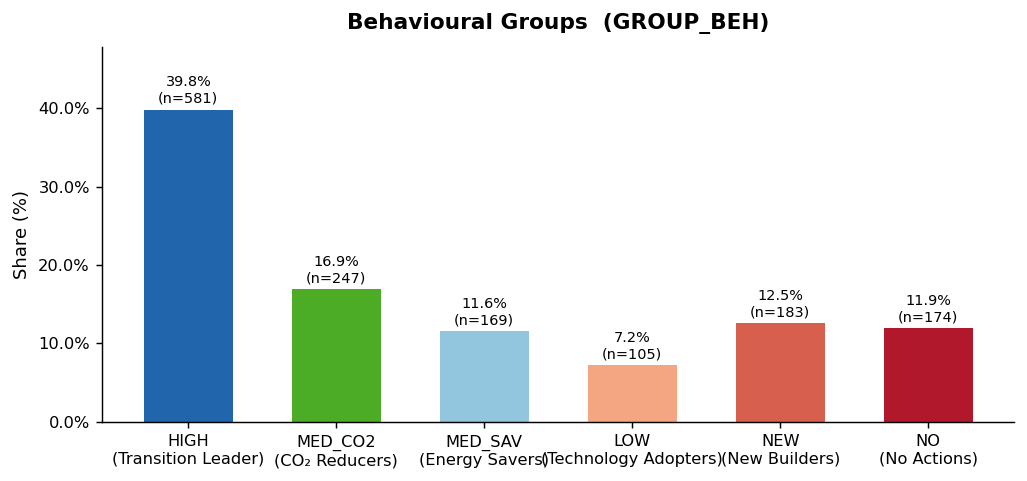

In [12]:
# ── 1b: Behavioural groups (GROUP_BEH) ────────────────────────────────────────
group_labels = {
    "1": "HIGH\n(Transition Leader)",
    "2": "MED_CO2\n(CO₂ Reducers)",
    "3": "MED_SAV\n(Energy Savers)",
    "4": "LOW\n(Technology Adopters)",
    "5": "NEW\n(New Builders)",
    "6": "NO\n(No Actions)",
}

grp_raw    = get_field("GROUP_BEH")
grp_counts = Counter(grp_raw)
keys       = sorted(grp_counts, key=int)
labels     = [group_labels[k] for k in keys]
counts     = [grp_counts[k] for k in keys]
pcts       = pct_of(counts)

colors_grp = ["#2166ac", "#4dac26", "#92c5de", "#f4a582", "#d6604d", "#b2182b"]

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(labels, pcts, color=colors_grp, width=0.6)
ax.set_title("Behavioural Groups  (GROUP_BEH)", pad=10)
ax.set_ylabel("Share (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(pcts) * 1.2)
for bar, pct, cnt in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{pct:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

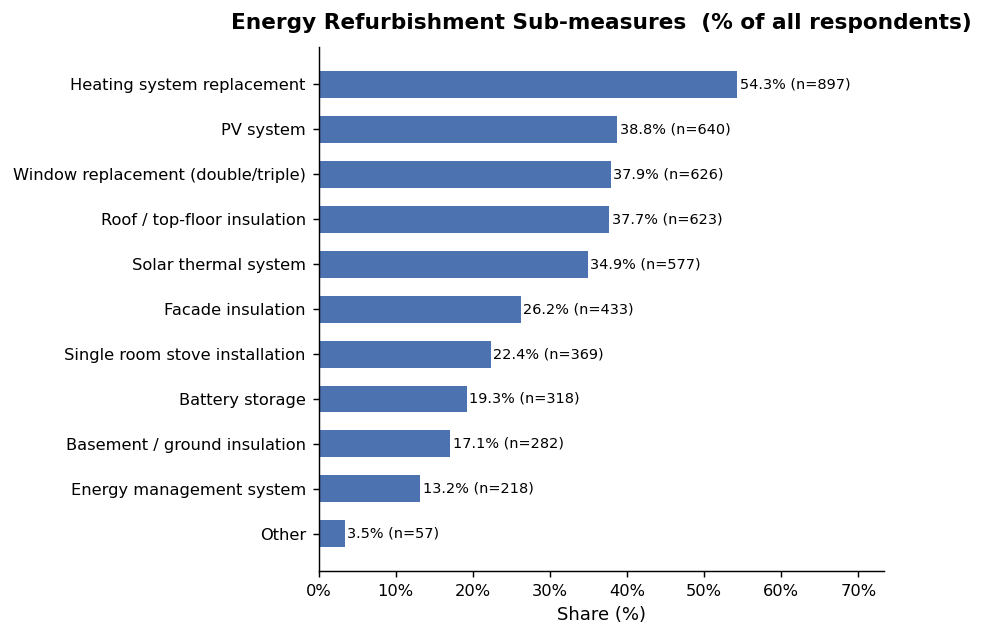

In [13]:
# ── 1c: Energy refurbishment sub-measures (REF_1 … REF_11) ───────────────────
ref_fields = [f"REF_{i}" for i in range(1, 12)]
ref_labels = [
    "Facade insulation",
    "Roof / top-floor insulation",
    "Basement / ground insulation",
    "Window replacement (double/triple)",
    "Heating system replacement",
    "Single room stove installation",
    "Solar thermal system",
    "PV system",
    "Battery storage",
    "Energy management system",
    "Other",
]

ref_yes = [
    sum(1 for r in data if str(r.get(f, '0')) == '1')
    for f in ref_fields
]
ref_pcts = pct_of(ref_yes, N)

# Sort descending
order = sorted(range(len(ref_pcts)), key=lambda i: ref_pcts[i])
sorted_labels = [ref_labels[i] for i in order]
sorted_pcts   = [ref_pcts[i]   for i in order]
sorted_counts = [ref_yes[i]    for i in order]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(sorted_labels, sorted_pcts, color=C_MEAS, height=0.6)
ax.set_title("Energy Refurbishment Sub-measures  (% of all respondents)", pad=10)
ax.set_xlabel("Share (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, pct, cnt in zip(bars, sorted_pcts, sorted_counts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={cnt})", va="center", fontsize=8)
ax.set_xlim(0, max(sorted_pcts) * 1.35)
plt.tight_layout()
plt.show()

---
## 3 · Sociodemographics

In [ ]:
# ── 3a: Gender ────────────────────────────────────────────────────────────────
gender_map = {"1": "Female", "2": "Male", "3": "Other"}

g_raw    = Counter(get_field("SOCIO_Gender1"))
g_keys   = sorted(g_raw, key=int)
g_vals   = [g_raw[k] for k in g_keys]
g_labels = [f"{gender_map[k]}\n(n={g_raw[k]})" for k in g_keys]

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.pie(g_vals, labels=g_labels, autopct="%1.1f%%",
       colors=[C_SOCIO, "#4C72B0", "#aaaaaa"], startangle=90,
       textprops={"fontsize": 9})
ax.set_title("Gender Distribution  (SOCIO_Gender1)", pad=10)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3b: Age distribution (birth year → age in 2024) ───────────────────────────
SURVEY_YEAR = 2024

ages = [SURVEY_YEAR - int(r["SOCIO_Age1"])
        for r in data if r.get("SOCIO_Age1") is not None]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=range(min(ages), max(ages) + 2, 5),
        color=C_SOCIO, edgecolor="white", linewidth=0.5)
ax.set_title(f"Age Distribution of Respondents  (calculated as {SURVEY_YEAR} − birth year)", pad=10)
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.axvline(np.mean(ages), color="#333", linestyle="--", linewidth=1.2,
           label=f"Mean: {np.mean(ages):.1f} years")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3c: Education & Income (side by side) ─────────────────────────────────────
edu_map = {
    "1": "Primary school",
    "2": "Vocational /\nApprenticeship",
    "3": "Secondary school\n(Matura)",
    "4": "University /\nCollege",
    "5": "No degree",
}

inc_map = {
    "1": "<1,500€",
    "2": "1,500–3,000€",
    "3": "3,000–4,500€",
    "4": "4,500–6,000€",
    "5": "6,000–7,500€",
    "6": ">7,500€",
    "7": "No answer",
}

edu_raw  = Counter(get_field("HOUSE_Education"))
inc_raw  = Counter(get_field("HOUSE_Income"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Education
e_keys  = sorted(edu_raw, key=int)
e_vals  = [edu_raw[k] for k in e_keys]
e_lbl   = [edu_map[k] for k in e_keys]
e_pcts  = pct_of(e_vals)
bars = axes[0].bar(e_lbl, e_pcts, color=C_SOCIO, width=0.6)
axes[0].set_title("Highest Education in Household  (HOUSE_Education)", pad=10)
axes[0].set_ylabel("Share (%)")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, max(e_pcts) * 1.2)
for bar, pct in zip(bars, e_pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

# Income
i_keys  = sorted(inc_raw, key=int)
i_vals  = [inc_raw[k] for k in i_keys]
i_lbl   = [inc_map.get(k, k) for k in i_keys]
i_pcts  = pct_of(i_vals)
bars = axes[1].bar(i_lbl, i_pcts, color=C_SOCIO, width=0.6)
axes[1].set_title("Monthly Net Household Income  (HOUSE_Income)", pad=10)
axes[1].set_ylabel("Share (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, max(i_pcts) * 1.2)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
for bar, pct in zip(bars, i_pcts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# ── 4a: Trigger statements — stacked Likert bar ───────────────────────────────
# Scale: 1=Fully agree, 2=Rather agree, 3=Rather disagree, 4=Fully disagree, 5=Don't know
trig_fields = ["TRIG_1", "TRIG_2", "TRIG_3", "TRIG_4"]
trig_labels = [
    "Used a good\nopportunity",
    "Prevented future\nenergy/climate crisis",
    "Prevented building\nmaintenance problems",
    "Followed others'\nrecommendations",
]
likert_labels  = ["Fully agree", "Rather agree", "Rather disagree", "Fully disagree", "Don't know"]
likert_colors  = ["#2166ac", "#92c5de", "#f4a582", "#d7191c", "#cccccc"]
likert_vals    = ["1", "2", "3", "4", "5"]

trig_data = {}
for field in trig_fields:
    vals  = get_field(field)
    total = len(vals)
    trig_data[field] = [vals.count(v) / total * 100 for v in likert_vals]

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(trig_fields))
left  = np.zeros(len(trig_fields))

for i, (lbl, color) in enumerate(zip(likert_labels, likert_colors)):
    widths = [trig_data[f][i] for f in trig_fields]
    bars   = ax.barh(y_pos, widths, left=left, color=color, height=0.55, label=lbl)
    for bar, w in zip(bars, widths):
        if w > 4:   # only label if wide enough
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.0f}%", ha="center", va="center", fontsize=7.5, color="white")
    left += np.array(widths)

ax.set_yticks(y_pos + 2)
ax.set_yticklabels(trig_labels, fontsize=9)
ax.set_xlabel("Share (%)")
ax.set_title("Trigger Statements for Renovation  (Likert scale, 1=Fully agree)", pad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 102)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
# ── 4b: Subsidy uptake + subsidy types ────────────────────────────────────────
sub_map = {"0": "No", "1": "Yes", "2": "Don't know"}

sub_raw    = Counter(get_field("SUB"))
sub_keys   = sorted(sub_raw, key=int)
sub_vals   = [sub_raw[k] for k in sub_keys]
sub_labels = [f"{sub_map[k]}\n(n={sub_raw[k]})" for k in sub_keys]

type_fields = ["SUB_1", "SUB_2", "SUB_3", "SUB_4", "SUB_5"]
type_labels = ["Federal funding", "State (Land) funding",
               "Municipal funding", "Other", "Don't know"]
type_counts = [sum(1 for r in data if str(r.get(f, '')) == '1') for f in type_fields]
# base = respondents who received a subsidy
sub_yes_n   = sub_raw.get("1", 0)
type_pcts   = [c / sub_yes_n * 100 if sub_yes_n else 0 for c in type_counts]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie — subsidy uptake
axes[0].pie(sub_vals, labels=sub_labels, autopct="%1.1f%%",
            colors=["#d7191c", C_TRIG, "#cccccc"], startangle=90,
            textprops={"fontsize": 9})
axes[0].set_title("Subsidy Uptake  (SUB)", pad=10)

# Bar — subsidy types (among those who received any)
bars = axes[1].barh(type_labels[::-1], type_pcts[::-1], color=C_TRIG, height=0.55)
axes[1].set_title(f"Subsidy Types  (% of subsidy recipients, n={sub_yes_n})", pad=10)
axes[1].set_xlabel("Share (%)")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, pct, cnt in zip(bars, type_pcts[::-1], type_counts[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{pct:.1f}% (n={cnt})", va="center", fontsize=8.5)
axes[1].set_xlim(0, max(type_pcts) * 1.35)

plt.tight_layout()
plt.show()

In [ ]:
# ── 4c: Subsidy uptake by behavioural group (grouped bar) ─────────────────────
grp_short = {
    "1": "HIGH", "2": "MED_CO2", "3": "MED_SAV",
    "4": "LOW",  "5": "NEW",     "6": "NO",
}

grp_order = ["1", "2", "3", "4", "5", "6"]
sub_by_grp_yes = []
sub_by_grp_no  = []
grp_ns         = []

for g in grp_order:
    members = [r for r in data if str(r.get("GROUP_BEH", "")) == g]
    n_total = len(members)
    n_yes   = sum(1 for r in members if str(r.get("SUB", "")) == "1")
    n_no    = sum(1 for r in members if str(r.get("SUB", "")) == "0")
    sub_by_grp_yes.append(n_yes / n_total * 100 if n_total else 0)
    sub_by_grp_no.append(n_no  / n_total * 100 if n_total else 0)
    grp_ns.append(n_total)

x     = np.arange(len(grp_order))
w     = 0.35
xlbls = [f"{grp_short[g]}\n(n={grp_ns[i]})" for i, g in enumerate(grp_order)]

fig, ax = plt.subplots(figsize=(9, 4))
bars_yes = ax.bar(x - w/2, sub_by_grp_yes, w, label="Received subsidy", color=C_TRIG)
bars_no  = ax.bar(x + w/2, sub_by_grp_no,  w, label="No subsidy",       color="#aaaaaa")
ax.set_title("Subsidy Uptake by Behavioural Group", pad=10)
ax.set_ylabel("Share within group (%)")
ax.set_xticks(x)
ax.set_xticklabels(xlbls, fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
for bar in list(bars_yes) + list(bars_no):
    h = bar.get_height()
    if h > 3:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                f"{h:.0f}%", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()